In [838]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import datetime

In [839]:
holiday_list = pd.read_csv("data/holiday_list.csv")
outlet_cordinates = pd.read_csv("data/outlet_coordinates.csv")
outlet_master = pd.read_csv("data/outlet_master.csv")
transaction_history = pd.read_csv("data/transactions_history_final.csv")
distributor_seasonality_details = pd.read_csv("data/distributor_seasonality_details.csv")

In [840]:
# create bronze layer

In [841]:
# create lake house dirs
dirs: list[str] = ["lakehouse/bronze", "lakehouse/silver", "lakehouse/quarantine", "lakehouse/gold"]
for d in dirs:
    Path(d).mkdir(parents=True, exist_ok=True)

In [842]:
# read files in data (raw data)\
source_file_paths: list[str] = [f"data/{path}" for path in os.listdir("data")]
source_file_paths

['data/distributor_seasonality_details.csv',
 'data/holiday_list.csv',
 'data/outlet_coordinates.csv',
 'data/outlet_master.csv',
 'data/transactions_history_final.csv']

In [843]:
LAKE_HOUSE_BRONZE_PATH = "lakehouse/bronze"
for path in source_file_paths:
    df = pd.read_csv(path)
    file_name, _ = path.rsplit(".")
    file_name = file_name.rsplit("/")[-1]
    # add meta data
    # :TODO for future ref we are goona drop this any way so dont add this and remove drop code in gold layer after 
    df["_ingested_at"] = pd.to_datetime(datetime.now())
    df["_source_file"] = path

    df.to_parquet(Path(f"{LAKE_HOUSE_BRONZE_PATH}/{file_name}.parquet"),compression="zstd", index=False)


In [844]:
from utils.preprocessing import check_duplicates, check_nulls, check_referential_integrity, check_value_range, check_format, check_geo_bounds, check_datetime_format, fix_outlet_type
from utils.helpers import save_sliver

from utils.preprocessing import fix_outlet_size

In [845]:
#silver layer


In [846]:
LAKE_HOUSE_SILVER_PATH = "lakehouse/silver"
os.listdir('lakehouse/bronze')

['distributor_seasonality_details.parquet',
 'holiday_list.parquet',
 'outlet_coordinates.parquet',
 'outlet_master.parquet',
 'transactions_history_final.parquet']

In [847]:
# holidaylist
df = pd.read_parquet('lakehouse/bronze/holiday_list.parquet')
dataset_name = 'holiday_list'
df = check_nulls(df, df.columns, dataset_name)
df = check_duplicates(df, df.columns, dataset_name)
df = check_datetime_format(df, 'Date', dataset_name=dataset_name)
df = check_format(df, 'Holiday_Type', 'category', dataset_name)
save_sliver(df, dataset_name, LAKE_HOUSE_SILVER_PATH)
holiday_list = df

In [848]:
tmp = pd.read_parquet('lakehouse/silver/holiday_list.parquet')
tmp.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   Date          256 non-null    datetime64[us, UTC]
 1   Holiday_Name  256 non-null    str                
 2   Holiday_Type  256 non-null    category           
 3   _ingested_at  256 non-null    datetime64[us]     
 4   _source_file  256 non-null    str                
dtypes: category(1), datetime64[us, UTC](1), datetime64[us](1), str(2)
memory usage: 20.6 KB


In [849]:
holiday_list['Date'].head()

0   2023-01-06 00:00:00+00:00
1   2023-01-15 00:00:00+00:00
2   2023-01-16 00:00:00+00:00
3   2023-02-03 00:00:00+00:00
4   2023-02-04 00:00:00+00:00
Name: Date, dtype: datetime64[us, UTC]

In [850]:
# outlet coordinates
df = pd.read_parquet('lakehouse/bronze/outlet_coordinates.parquet')
dataset_name = 'outlet_coordinates'
df = check_nulls(df, df.columns, dataset_name)
df = check_duplicates(df, ['Outlet_ID'], dataset_name)
df = check_geo_bounds(df, 'Latitude', 'Longitude', dataset_name)
save_sliver(df, dataset_name, LAKE_HOUSE_SILVER_PATH)
outlet_cordinates = df
# has 0,0 value we need to drop it
#df.plot(kind='scatter', x='Longitude', y='Latitude')

In [851]:
#outlet_master check

df = pd.read_parquet('lakehouse/bronze/outlet_master.parquet')
dataset_name = 'outlet_master'

df = check_nulls(df, df.columns, dataset_name)

In [852]:
df = fix_outlet_type(df, dataset_name=dataset_name)
df = fix_outlet_size(df, dataset_name=dataset_name)
df = check_duplicates(df, df.columns, dataset_name)
df = check_referential_integrity(df, 'Outlet_ID', outlet_cordinates, 'Outlet_ID', dataset_name)
df = check_format(df, ['Outlet_Type', 'Outlet_Size'], 'category', dataset_name)
df = check_format(df, 'Outlet_ID', 'string', dataset_name)
save_sliver(df, dataset_name, LAKE_HOUSE_SILVER_PATH)
outlet_master = df
outlet_master.info()

<class 'pandas.DataFrame'>
Index: 19764 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Outlet_ID     19764 non-null  string        
 1   Outlet_Size   19764 non-null  category      
 2   Cooler_Count  19764 non-null  int64         
 3   Outlet_Type   19764 non-null  category      
 4   _ingested_at  19764 non-null  datetime64[us]
 5   _source_file  19764 non-null  str           
dtypes: category(2), datetime64[us](1), int64(1), str(1), string(1)
memory usage: 1.4 MB


In [853]:
# distributer_seasonality
# :TODO fix year month data type
df = pd.read_parquet('lakehouse/bronze/distributor_seasonality_details.parquet')
dataset_name = 'distributor_seasonality_details'
df = check_duplicates(df, ['Distributor_ID', 'Year', 'Month'], dataset_name)
df = check_nulls(df, df.columns, dataset_name)
df = check_format(df, 'Seasonality_Index', 'category', dataset_name)
save_sliver(df, dataset_name, LAKE_HOUSE_SILVER_PATH)
distributor_seasonality_details = df

In [854]:
df = pd.read_parquet('lakehouse/bronze/transactions_history_final.parquet')
dataset_name = 'transactions_history'
df = check_duplicates(df, ['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID'], 'transactions')
df = check_nulls(df, df.columns, dataset_name)
df = check_referential_integrity(df, 'Outlet_ID', outlet_cordinates, 'Outlet_ID', dataset_name)
df = check_referential_integrity(df, 'Distributor_ID', distributor_seasonality_details, 'Distributor_ID', dataset_name)
# :TODO! chagne in to a resonable value and fix year month data type
df = check_value_range(df, 'Volume_Liters', 0, np.inf, dataset_name)
df = check_value_range(df, 'Total_Bill_Value', 0, np.inf, dataset_name)
save_sliver(df, dataset_name, LAKE_HOUSE_SILVER_PATH)
transaction_history = df


In [855]:
transaction_history.info()

<class 'pandas.DataFrame'>
Index: 2334830 entries, 0 to 2376388
Data columns (total 9 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Outlet_ID         str           
 1   Year              int64         
 2   Month             int64         
 3   Distributor_ID    str           
 4   SKU_ID            str           
 5   Volume_Liters     float64       
 6   Total_Bill_Value  float64       
 7   _ingested_at      datetime64[us]
 8   _source_file      str           
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 311.1 MB


In [856]:
holiday_list.info()

<class 'pandas.DataFrame'>
Index: 256 entries, 0 to 348
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   Date          256 non-null    datetime64[us, UTC]
 1   Holiday_Name  256 non-null    str                
 2   Holiday_Type  256 non-null    category           
 3   _ingested_at  256 non-null    datetime64[us]     
 4   _source_file  256 non-null    str                
dtypes: category(1), datetime64[us, UTC](1), datetime64[us](1), str(2)
memory usage: 22.5 KB


In [857]:
# gold layer

In [858]:
#poi part

In [859]:
# !wget https://download.geofabrik.de/asia/sri-lanka-latest.osm.pbf

In [860]:
from utils.helpers import parse_poi

In [861]:
INPUT_FILE = "lakehouse/silver/outlet_coordinates.parquet"
OUTPUT_FILE = "lakehouse/gold/poi_features.parquet"
PBF_FILE = "sri-lanka-260515.osm.pbf"
RADIUS_M = 1500
parse_poi(input_file=INPUT_FILE, output_file=OUTPUT_FILE, pbf_file=PBF_FILE, radius=RADIUS_M)

1. Reading map data from local PBF file using QuackOSM...


-> Extracted 15925 total POIs from the map.

2. Loading your outlet coordinates...

3. Projecting and buffering geometries to 1500m...

4. Performing spatial join... (The fast part!)

5. Aggregating and formatting results...

Done! Processed 19960 outlets in 0.70 seconds.
Saved to: lakehouse/gold/poi_features.parquet


In [862]:
# Load the generated POI features
poi_features = pd.read_parquet('lakehouse/gold/poi_features.parquet')
poi_features.describe()

,poi_bus_stop_1500m,poi_hospital_1500m,poi_market_1500m,poi_school_1500m,poi_supermarket_1500m,poi_tourism_1500m
count,19960.000000,19960.000000,19960.000000,19960.000000,19960.000000,19960.000000
mean,1.464880,0.394589,0.137625,2.019539,0.964329,1.647495
std,4.645364,1.421532,0.516327,5.586519,2.752137,7.566211
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000
max,59.000000,23.000000,8.000000,73.000000,32.000000,165.000000


In [863]:
tx = pd.read_parquet('lakehouse/silver/transactions_history.parquet')
outlet_cordinates = pd.read_parquet('lakehouse/silver/outlet_coordinates.parquet')
outlet_master = pd.read_parquet('lakehouse/silver/outlet_master.parquet')
distributor_seasonality_details = pd.read_parquet('lakehouse/silver/distributor_seasonality_details.parquet')
holiday_list = pd.read_parquet('lakehouse/silver/holiday_list.parquet')

In [864]:
#gold layer

In [865]:
# join oulet_master and outlet_corrdinates
outlet_full = pd.merge(
    outlet_master,
    outlet_cordinates[['Outlet_ID', 'Latitude', 'Longitude']],
    on='Outlet_ID',
    how='left',
)
outlet_full

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,_ingested_at,_source_file,Latitude,Longitude
0,OUT_00001,Medium,1,Grocery,2026-05-16 22:49:52.164760,data/outlet_master.csv,7.089846,79.979055
1,OUT_00002,Small,0,Hotel,2026-05-16 22:49:52.164760,data/outlet_master.csv,7.000558,80.012422
2,OUT_00003,Small,1,Pharmacy,2026-05-16 22:49:52.164760,data/outlet_master.csv,6.806170,79.854547
3,OUT_00004,Medium,2,Pharmacy,2026-05-16 22:49:52.164760,data/outlet_master.csv,6.703533,79.806919
4,OUT_00005,Medium,2,Kiosk,2026-05-16 22:49:52.164760,data/outlet_master.csv,7.186878,79.869831
...,...,...,...,...,...,...,...,...
19759,OUT_19996,Medium,2,SMMT,2026-05-16 22:49:52.164760,data/outlet_master.csv,6.137766,80.201222
19760,OUT_19997,Small,1,Kiosk,2026-05-16 22:49:52.164760,data/outlet_master.csv,6.147838,80.282401
19761,OUT_19998,Medium,1,Hotel,2026-05-16 22:49:52.164760,data/outlet_master.csv,5.901855,80.318880
19762,OUT_19999,Small,0,Bakery,2026-05-16 22:49:52.164760,data/outlet_master.csv,6.074594,80.545045


In [866]:
# join tx, ,outlet, sesonality, 
gold_df = pd.merge(
    tx,
    outlet_full.drop(columns=['_ingested_at', '_source_file'], errors='ignore'),
    on='Outlet_ID',
    how='inner',
)
gold_df = pd.merge(
    gold_df,
    distributor_seasonality_details.drop(columns=['_ingested_at', '_source_file'], errors='ignore'),
    on=['Distributor_ID', 'Year', 'Month'],
    how='left',
)
gold_df.head()


,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value,_ingested_at,_source_file,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Seasonality_Index
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359,2026-05-16 22:49:54.214970,data/transactions_history_final.csv,Small,0,Hotel,6.222572,80.230934,Favorable
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814,2026-05-16 22:49:54.214970,data/transactions_history_final.csv,Large,4,Kiosk,7.024894,79.831030,Moderate
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787,2026-05-16 22:49:54.214970,data/transactions_history_final.csv,Medium,1,Grocery,7.537159,80.103760,Favorable
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773,2026-05-16 22:49:54.214970,data/transactions_history_final.csv,Medium,2,Bakery,7.152607,80.666430,Moderate
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656,2026-05-16 22:49:54.214970,data/transactions_history_final.csv,Extra Large,5,Kiosk,6.994638,80.647910,Moderate


In [867]:
#add holidays
holiday_tmp = holiday_list.copy()
holiday_tmp['Year']  = holiday_tmp['Date'].dt.year
holiday_tmp['Month'] = holiday_tmp['Date'].dt.month
holiday_counts = (
    holiday_tmp
    .groupby(['Year', 'Month'])
    .size()
    .to_frame(name='Holiday_Count')
    .reset_index()
)
 
gold_df = pd.merge(gold_df, holiday_counts, on=['Year', 'Month'], how='left')
gold_df['Holiday_Count'] = gold_df['Holiday_Count'].fillna(0).astype(int)


In [868]:
#add_poi
gold_df = pd.merge(gold_df, poi_features, on='Outlet_ID', how='left')

In [869]:
# remove this later
cols = ['_ingested_at', '_source_file']
gold_df.drop(columns=cols, inplace=True)

# add correct types
int_cols = [
    'Year', 'Month',
    'poi_bus_stop_1500m', 'poi_hospital_1500m', 'poi_market_1500m',
    'poi_school_1500m',   'poi_supermarket_1500m', 'poi_tourism_1500m',
]
float_cols = ['Volume_Liters', 'Total_Bill_Value', 'Cooler_Count', 'Latitude', 'Longitude']
 
for col in int_cols:
    if col in gold_df.columns:
        gold_df[col] = pd.to_numeric(gold_df[col], downcast='integer')
 
for col in float_cols:
    if col in gold_df.columns:
        gold_df[col] = pd.to_numeric(gold_df[col], downcast='float')

In [870]:
LAKE_HOUSE_GOLD_PATH = 'lakehouse/gold'
gold_df.to_parquet(f'{LAKE_HOUSE_GOLD_PATH}/master_features.parquet', compression='zstd', index=False)

In [871]:
df = pd.read_parquet('lakehouse/gold/master_features.parquet')

In [872]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2323705 entries, 0 to 2323704
Data columns (total 20 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Outlet_ID              str     
 1   Year                   int16   
 2   Month                  int8    
 3   Distributor_ID         str     
 4   SKU_ID                 str     
 5   Volume_Liters          float32 
 6   Total_Bill_Value       float64 
 7   Outlet_Size            category
 8   Cooler_Count           float32 
 9   Outlet_Type            category
 10  Latitude               float32 
 11  Longitude              float32 
 12  Seasonality_Index      category
 13  Holiday_Count          int64   
 14  poi_bus_stop_1500m     int8    
 15  poi_hospital_1500m     int8    
 16  poi_market_1500m       int8    
 17  poi_school_1500m       int8    
 18  poi_supermarket_1500m  int8    
 19  poi_tourism_1500m      int16   
dtypes: category(3), float32(4), float64(1), int16(2), int64(1), int8(6), str(3)
mem

In [873]:
# -- data is ready for eda

In [874]:
import matplotlib.pyplot as plt
import seaborn as sns

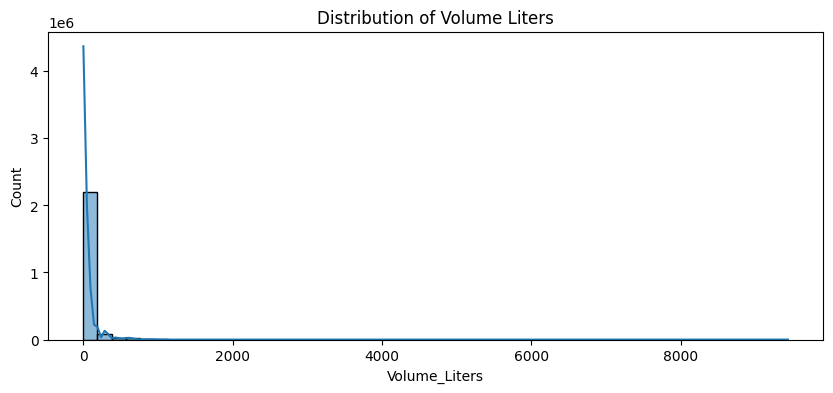

In [875]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Volume_Liters'], kde=True, bins=50)
plt.title('Distribution of Volume Liters')
plt.show()

In [876]:
threshold = df['Volume_Liters'].quantile(0.99)
high_volume_df = df[df['Volume_Liters'] > threshold]

high_volume_df['Outlet_Size'].value_counts()

Outlet_Size
Extra Large    23184
Large             52
Medium             1
Small              1
Name: count, dtype: int64

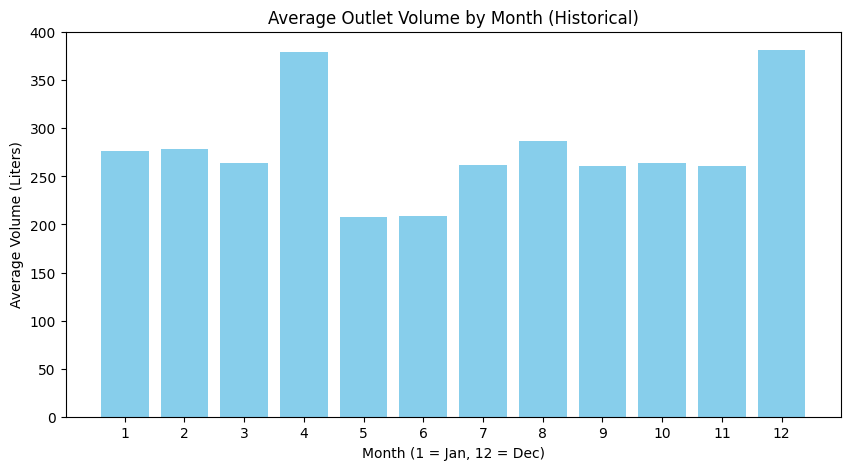

In [877]:
monthly_outlet_vol = df.groupby(['Year', 'Month', 'Outlet_ID'])['Volume_Liters'].sum().reset_index()

avg_monthly_vol = monthly_outlet_vol.groupby('Month')['Volume_Liters'].mean().reset_index()

avg_monthly_vol_sorted = avg_monthly_vol.sort_values(by='Volume_Liters', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(avg_monthly_vol['Month'], avg_monthly_vol['Volume_Liters'], color='skyblue')
plt.title('Average Outlet Volume by Month (Historical)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Average Volume (Liters)')
plt.xticks(range(1, 13))
plt.show()

In [878]:
df.Seasonality_Index.value_counts()

Seasonality_Index
Moderate        1611153
Favorable        479835
Un-Favorable     232717
Name: count, dtype: int64

In [879]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [880]:
aggregation_rules = {
    'Volume_Liters': 'sum',    
    'Total_Bill_Value': 'sum',  
    'Cooler_Count': 'first',     
    'Outlet_Size': 'first',       
    'Outlet_Type': 'first',        
    'Latitude': 'first',            
    'Longitude': 'first',            
    'Seasonality_Index': 'first',     
    'Holiday_Count': 'first',         
    'poi_bus_stop_1500m': 'first',    
    'poi_hospital_1500m': 'first',    
    'poi_market_1500m': 'first',      
    'poi_school_1500m': 'first',      
    'poi_supermarket_1500m': 'first', 
    'poi_tourism_1500m': 'first'
}

In [881]:
df_monthly = df.groupby(['Outlet_ID', 'Year', 'Month']).agg(aggregation_rules).reset_index()

In [882]:
#calculate hist max
historical_max = df_monthly.groupby('Outlet_ID')['Volume_Liters'].max().reset_index()
#historical_max.head()

In [883]:
historical_max.rename(columns={'Volume_Liters': 'Historical_Max_Volume'}, inplace=True)
df_monthly = df_monthly.merge(historical_max, on='Outlet_ID', how='left')
#df_monthly.head(100)

In [884]:
outlet_agg = df_monthly.groupby('Outlet_ID').agg(
    cv        = ('Volume_Liters', lambda x: x.std() / x.mean() if x.mean() > 0 else 0),
    repeat_r  = ('Volume_Liters', lambda x: 1 - x.nunique() / len(x)),
    round_r   = ('Volume_Liters', lambda x: (x % 10 == 0).mean()),
).reset_index()

outlet_agg['is_censored'] = (
    (outlet_agg['cv'] < 0.15).astype(int) +
    (outlet_agg['repeat_r'] > 0.5).astype(int) +
    (outlet_agg['round_r'] > 0.7).astype(int)
) >= 2

df_monthly = df_monthly.merge(outlet_agg[['Outlet_ID', 'is_censored']], on='Outlet_ID')

In [885]:
cohort_p90 = df_monthly.groupby(['Outlet_Type', 'Outlet_Size'])['Volume_Liters'] \
    .quantile(0.90).reset_index().rename(columns={'Volume_Liters': 'cohort_p90'})

df_monthly = df_monthly.merge(cohort_p90, on=['Outlet_Type', 'Outlet_Size'], how='left')

In [886]:
outlet_level = df_monthly.groupby('Outlet_ID').agg(
    Cooler_Count         = ('Cooler_Count', 'first'),
    Latitude             = ('Latitude', 'first'),
    Longitude            = ('Longitude', 'first'),
    Outlet_Size          = ('Outlet_Size', 'first'),
    Outlet_Type          = ('Outlet_Type', 'first'),
    poi_bus_stop_1500m   = ('poi_bus_stop_1500m', 'first'),
    poi_hospital_1500m   = ('poi_hospital_1500m', 'first'),
    poi_market_1500m     = ('poi_market_1500m', 'first'),
    poi_school_1500m     = ('poi_school_1500m', 'first'),
    poi_supermarket_1500m= ('poi_supermarket_1500m', 'first'),
    poi_tourism_1500m    = ('poi_tourism_1500m', 'first'),
    cohort_p90           = ('cohort_p90', 'first'),
    is_censored          = ('is_censored', 'first'),
    target               = ('Volume_Liters', 'max'),
).reset_index()

outlet_level['target'] = np.where(
    outlet_level['is_censored'],
    outlet_level['cohort_p90'],
    outlet_level['target']
)

# make it numerical cause feature importance without this is 9
size_order = {'Small': 1, 'Medium': 2, 'Large': 3, 'Extra Large': 4}
outlet_level['Outlet_Size_Ord'] = outlet_level['Outlet_Size'].astype(str).map(size_order).fillna(1)

In [887]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

coords = outlet_level[['Latitude', 'Longitude']].values

# find natural clusters in your actual outlet distribution
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
outlet_level['cluster'] = kmeans.fit_predict(coords)
centers = kmeans.cluster_centers_

# distance to nearest cluster center = urbanness proxy
dists = cdist(coords, centers, metric='euclidean')
outlet_level['dist_to_nearest_center'] = dists.min(axis=1)

# density of each cluster = how many outlets share this center
cluster_density = outlet_level['cluster'].value_counts().rename('cluster_density')
outlet_level = outlet_level.merge(cluster_density, left_on='cluster', right_index=True)

In [888]:
#print(outlet_level['target'].quantile(0.99))

cap = outlet_level['target'].quantile(0.99)
outlet_level['target'] = outlet_level['target'].clip(upper=cap)

In [889]:
# Elbow method
# inertias = []
# for k in range(5, 40):
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     km.fit(coords)
#     inertias.append((k, km.inertia_))

In [890]:
# k_values = [item[0] for item in inertias]
# inertia_values = [item[1] for item in inertias]

# plt.figure(figsize=(10, 6))
# plt.plot(k_values, inertia_values, marker='o', linestyle='--', color='b')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
# plt.title('Elbow Method For Optimal k')
# plt.xticks(k_values)
# plt.grid(True)
# plt.show()

In [891]:
features = [
    'Cooler_Count',
    'poi_bus_stop_1500m', 'poi_hospital_1500m', 'poi_market_1500m',
    'poi_school_1500m', 'poi_supermarket_1500m', 'poi_tourism_1500m',
    'Outlet_Size_Ord', 'Outlet_Type', 'cohort_p90', 'dist_to_nearest_center','cluster_density', 'cluster'
]
cat_cols = ['Outlet_Type']

X_train = outlet_level[features]
y_train = outlet_level['target']   # already the ceiling

# Drop quantile objective — you've already built the ceiling into y_train
# Use regular regression to predict it cleanly
model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, categorical_feature=cat_cols)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 567
[LightGBM] [Info] Number of data points in the train set: 19764, number of used features: 13
[LightGBM] [Info] Start training from score 389.488003
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [892]:
outlets_2026 = outlet_level[['Outlet_ID'] + features].copy()
outlets_2026 = outlets_2026.merge(outlet_dist, on='Outlet_ID', how='left')
outlets_2026 = outlets_2026.merge(jan_season, on='Distributor_ID', how='left')

season_map = {'Favorable': 1.2, 'Moderate': 1.0, 'Un-Favorable': 0.8}
outlets_2026['season_mult'] = outlets_2026['Seasonality_Index'].astype(str).map(season_map).fillna(1.0)

outlets_2026['Maximum_Monthly_Liters'] = (
    model.predict(outlets_2026[features]) * outlets_2026['season_mult']
)

outlets_2026['Maximum_Monthly_Liters'] = np.maximum(
    outlets_2026['Maximum_Monthly_Liters'],
    outlet_level.set_index('Outlet_ID')['target'].reindex(outlets_2026['Outlet_ID']).values
)

outlets_2026['Maximum_Monthly_Liters'] = outlets_2026['Maximum_Monthly_Liters'].clip(lower=0).round(2)
outlets_2026['Maximum_Monthly_Liters'].describe()

count    19764.000000
mean       420.091502
std        474.154900
min         79.840000
25%        136.970000
50%        190.860000
75%        374.780000
max       2491.840000
Name: Maximum_Monthly_Liters, dtype: float64

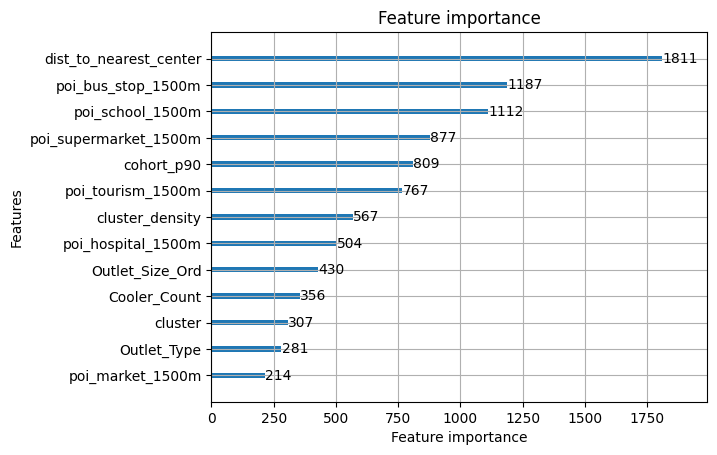

In [893]:
lgb.plot_importance(model, max_num_features=15)
plt.show()

In [896]:
submission = outlets_2026[['Outlet_ID', 'Maximum_Monthly_Liters']]

file_name = 'TechNova.csv'
submission.to_csv(file_name, index=False)